In [1]:
import gzip
import json
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import os

from matplotlib.backends.backend_pdf import PdfPages

sns.set();
%matplotlib inline

## Preprocess Clustering

 * choose max level of hierarchy
 * choose which sections to include
 * choose whether to ensure uniqueness of IDs

In [2]:
SPECIAL_SECTIONS = ['INTRODUCTION', 'CONCLUSION', 'PERSPECTIVES']

In [3]:
def is_box_section(title):
    if '|' not in title:
        return False
    return 'Box' in title.split('|')[0]

In [4]:
def preprocess_clustering_impl(clustering, max_level, current_level):
    current_level_elements = []
    clusters = []
    num_clusters = 0
    
#     print(max_level, current_level, clustering)
    for el in clustering:
        if isinstance(el, dict):
            inner_clusters, num_inner_clusters = preprocess_clustering_impl(el['references'], 
                                                                            max_level, current_level + 1)
#             print(inner_clusters, num_inner_clusters)
            if max_level <= current_level:
                current_level_elements.extend(inner_clusters)
            else:
                if num_inner_clusters == 1:
                    clusters.append(inner_clusters)
                else:
                    clusters.extend(inner_clusters)
                num_clusters += num_inner_clusters
        else:
            current_level_elements.append(el)
#         print(current_level_elements, clusters)
            
    if max_level <= current_level or not clusters:
        return current_level_elements, 1
    else:
        if current_level_elements:
            clusters.insert(0, current_level_elements)
            num_clusters += 1
        if num_clusters == 1:
            return clusters[0], num_clusters
        else:
            return clusters, num_clusters

def preprocess_clustering(clustering, max_level, 
                          include_special_sections=False,
                          include_box_sections=True):
    flat_clustering = []
    for section in clustering:
        is_special_section = section['title'] in SPECIAL_SECTIONS
        if not include_special_sections and is_special_section:
            continue
        if not include_box_sections and is_box_section(section['title']):
            continue
#         print(section)
        clusters, num_clusters = preprocess_clustering_impl(section['references'], max_level, 1)
#         print(clusters, num_clusters)
        if num_clusters == 1:
            flat_clustering.append(clusters)
        else:
            flat_clustering.extend(clusters)
    return flat_clustering

In [5]:
def get_clustering_level(clustering):
    levels = []
    for el in clustering:
        if isinstance(el, dict):
            levels.append(get_clustering_level(el['references']))
    if not levels:
        return 1
    else:
        return max(levels) + 1

In [6]:
def unique_ids_clustering(clustering, method):
    id_cluster = {}
    for i, cluster in enumerate(clustering):
        for pmid in cluster:
            if pmid not in id_cluster:
                id_cluster[pmid] = []
            id_cluster[pmid].append(i)
    if method == 'first_occurrence':
        return {str(k): v[0] for k, v in id_cluster.items()}
    elif method == 'unique_only':
        return {str(k): v[0] for k, v in id_cluster.items() if len(set(v)) == 1}

## Test Clustering Preprocessing

In [7]:
EXAMPLE_CLUSTERING_1 = [
    {
        'title': 'A',
        'references': [
            134,
            123,
            {
                'title': 'A.1',
                'references': [
                    {
                        'title': 'A.1.1',
                        'references': [
                            123,
                            324,
                        ]
                    },
                    {
                        'title': 'A.1.2',
                        'references': [
                            435
                        ]
                    }
                ]
            }
        ]
    },
    {
        'title': 'B',
        'references': [
            546,
            345
        ]
    },
    {
        'title': 'C',
        'references': [
            {
                'title': 'C.1',
                'references': [
                    234,
                    245
                ]
            }
        ]
    }
]

EXAMPLE_CLUSTERING_2 = [
    {
        'title': 'A',
        'references': [
            14,
            15,
            21
        ]
    },
    {
        'title': 'B',
        'references': [
            33,
            44,
            15
        ]
    }
]

EXAMPLE_CLUSTERING_3 = [
    {
        'title': 'INTRODUCTION',
        'references': [
            1,
            2,
            3
        ]
    },
    {
        'title': 'Box 1 | Box section',
        'references': [
            4,
            5,
            6
        ]
    }
]

In [8]:
preprocess_clustering(EXAMPLE_CLUSTERING_1, 1)

[[134, 123, 123, 324, 435], [546, 345], [234, 245]]

In [9]:
preprocess_clustering(EXAMPLE_CLUSTERING_1, 2)

[[134, 123], [123, 324, 435], [546, 345], [234, 245]]

In [10]:
preprocess_clustering(EXAMPLE_CLUSTERING_1, 3)

[[134, 123], [123, 324], [435], [546, 345], [234, 245]]

In [11]:
preprocess_clustering(EXAMPLE_CLUSTERING_3, 3)

[[4, 5, 6]]

In [12]:
preprocess_clustering(EXAMPLE_CLUSTERING_3, 3, include_special_sections=True, include_box_sections=False)

[[1, 2, 3]]

In [13]:
get_clustering_level(EXAMPLE_CLUSTERING_1)

4

In [14]:
get_clustering_level(EXAMPLE_CLUSTERING_2)

2

In [15]:
unique_ids_clustering(preprocess_clustering(EXAMPLE_CLUSTERING_1, 1), method='first_occurrence')

{'134': 0,
 '123': 0,
 '324': 0,
 '435': 0,
 '546': 1,
 '345': 1,
 '234': 2,
 '245': 2}

In [16]:
unique_ids_clustering(preprocess_clustering(EXAMPLE_CLUSTERING_1, 1), method='unique_only')

{'134': 0,
 '123': 0,
 '324': 0,
 '435': 0,
 '546': 1,
 '345': 1,
 '234': 2,
 '245': 2}

In [17]:
unique_ids_clustering(preprocess_clustering(EXAMPLE_CLUSTERING_1, 2), method='first_occurrence')

{'134': 0,
 '123': 0,
 '324': 1,
 '435': 1,
 '546': 2,
 '345': 2,
 '234': 3,
 '245': 3}

In [18]:
unique_ids_clustering(preprocess_clustering(EXAMPLE_CLUSTERING_1, 2), method='unique_only')

{'134': 0, '324': 1, '435': 1, '546': 2, '345': 2, '234': 3, '245': 3}

In [19]:
unique_ids_clustering(preprocess_clustering(EXAMPLE_CLUSTERING_2, 1), method='first_occurrence')

{'14': 0, '15': 0, '21': 0, '33': 1, '44': 1}

In [20]:
unique_ids_clustering(preprocess_clustering(EXAMPLE_CLUSTERING_2, 1), method='unique_only')

{'14': 0, '21': 0, '33': 1, '44': 1}

## Clustering Overview

In [28]:
CLUSTERING_FOLDER = '/home/willenjoy/work/pubtrends/nature_reviews/clustering/'

In [163]:
with PdfPages('clustering-overview.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level)
            n_clusters = len(processed_clustering)
            intersections = np.zeros((n_clusters, n_clusters))
            for i in range(n_clusters):
                for j in range(n_clusters):
                    common_elements = set(processed_clustering[i]).intersection(processed_clustering[j])
                    intersections[i, j] = len(common_elements)

            plt.figure(figsize = (10,7))
            sns.heatmap(intersections, annot=True)
            plt.title(f'{filename} - LEVEL {level}')
            pdf.savefig()
            plt.close()

## Estimate PubTrends quality for different clusterings

In [30]:
from pysrc.papers.analyzer import KeyPaperAnalyzer
from pysrc.papers.pubtrends_config import PubtrendsConfig
from pysrc.papers.db.loaders import Loaders

from sklearn.metrics.cluster import adjusted_rand_score, v_measure_score, \
                                    adjusted_mutual_info_score, contingency_matrix
from sklearn.metrics import fowlkes_mallows_score

In [22]:
PUBTRENDS_EXPORT_FOLDER = '/home/willenjoy/work/pubtrends/nature_reviews/pubtrends_export/'
PUBTRENDS_CONFIG = PubtrendsConfig(test=False)

In [23]:
def get_clustering(analyzer, target_ids):
    data = analyzer.df[analyzer.df['id'].isin(target_ids)]
    return {k: v for k, v in zip(data['id'], data['comp'])}

In [26]:
def evaluate_clustering(analyzer, ground_truth, metric):
    actual_clustering = get_clustering(analyzer, ground_truth.keys())
    
    # Align clusterings
    labels_true = []
    labels_pred = []

    for pmid in actual_clustering:
        labels_true.append(ground_truth[pmid])
        labels_pred.append(actual_clustering[pmid])
        
    return metric(labels_true, labels_pred), contingency_matrix(labels_true, labels_pred)

In [25]:
def reload_exported_analyzer(path_to_archive, source='Pubmed'):
    """
    Load analysis data from json.gz archive generated by PubTrends.
    """
    with gzip.open(path_to_archive, 'rt', encoding='UTF-8') as zipfile:
        data = json.load(zipfile)

    loader, url_prefix = Loaders.get_loader_and_url_prefix(source, PUBTRENDS_CONFIG)
    analyzer = KeyPaperAnalyzer(loader, PUBTRENDS_CONFIG)
    analyzer.init(data)
    
    return analyzer

In [246]:
def estimate_quality(metric, uniqueness_method, include_box_sections):
    pmids = []
    levels = []
    scores = []
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=include_box_sections)
            ground_truth = unique_ids_clustering(processed_clustering, method=uniqueness_method)
            score, _ = evaluate_clustering(analyzer, ground_truth, metric)
            print(pmid, level, score)
            pmids.append(pmid)
            levels.append(level)
            scores.append(score)
            
    return pmids, levels, scores 

In [253]:
COLOR_MAP = {1: '#455cf5', 2: '#33e836', 3: '#eb5021'}

In [254]:
scores_by_metric = {}

with PdfPages('pubtrends-quality.pdf') as pdf:
    for metric in [adjusted_rand_score, adjusted_mutual_info_score, v_measure_score, fowlkes_mallows_score]:
        for uniqueness_method in ['first_occurrence', 'unique_only']:
            for include_box_sections in [True, False]:
                print(metric.__name__, uniqueness_method, include_box_sections)
                pmids, levels, scores = estimate_quality(metric, uniqueness_method, include_box_sections)
                
                # Visualize
                colors = [COLOR_MAP[l] for l in levels]
    
                plt.figure(figsize=(10, 7))
                plt.scatter(pmids, scores, c=colors)
                plt.title(f'unique: {uniqueness_method} - include_box_sections: {include_box_sections}')
                plt.xlabel('PMID')
                plt.ylabel(metric.__name__)
                plt.xticks(rotation = 90)
                pdf.savefig()
                plt.close()
                
                if metric.__name__ not in scores_by_metric:
                    scores_by_metric[metric.__name__] = scores
                else:
                    scores_by_metric[metric.__name__].append(scores)

adjusted_rand_score first_occurrence True
26580716 1 0.054585589384975146
26580716 2 0.054390691215707734
26580717 1 0.10691013187195568
26580717 2 0.08248896949826479
26656254 1 0.24930143568882918
26656254 2 0.3328600051097933
26678314 1 0.07694009714778731
26678314 2 0.1266526556175216
26688349 1 0.3619604316546763
26688349 2 0.34123796281991864
26688350 1 0.08938480972224241
26688350 2 0.03297121336456369
27677859 1 -0.02691120430327489
27677859 2 -0.002112073891062688
27677860 1 -0.027522561045658166
27677860 2 0.0008327143160640739
27834397 1 -0.04747062534426711
27834397 2 0.010437067468561654
27834398 1 -0.018417912322819283
27834398 2 0.03920219122075426
27904142 1 0.17489674634631497
27904142 2 0.09843014320216631
28003656 1 0.07395362244720523
28003656 2 0.03142154786883908
28792006 1 0.06811777788784411
28792006 2 0.14549713083910537
28852220 1 -0.01474291016288735
28852220 2 0.02100426947106902
29147025 1 0.05861999994444001
29147025 2 0.055563096521854954
29147025 3 0.008

26580717 1 0.2692525662840898
26580717 2 0.23174726642808416
26656254 1 0.3913570372490705
26656254 2 0.4677217294211685
26678314 1 0.2118706101463541
26678314 2 0.3406107993856423
26688349 1 0.4643879540727328
26688349 2 0.4810741716823599
26688350 1 0.2785272023610532
26688350 2 0.10123631664695214
27677859 1 0.09426605235476596
27677859 2 0.11104211052253236
27677860 1 0.07050022769403873
27677860 2 0.10731471034801665
27834397 1 0.14951554611767004
27834397 2 0.19588905623090125
27834398 1 0.04954070092899973
27834398 2 0.13558683153507942
27904142 1 0.31615305213496836
27904142 2 0.31080362855532
28003656 1 0.20115091926750775
28003656 2 0.14292934027331755
28792006 1 0.24300405253950239
28792006 2 0.36186657212286205
28852220 1 0.030620281159230406
28852220 2 0.07069464492698457
29147025 1 0.05022888497935669
29147025 2 0.04722439436319511
29147025 3 0.0464811649580672
29170536 1 0.21460600742227062
29170536 2 0.23702001429933303
29170536 3 0.29623715826257396
29213134 1 0.098229

27677859 1 0.3692997289173213
27677859 2 0.20743757252292055
27677860 1 0.4491237225303024
27677860 2 0.2691048318520472
27834397 1 0.3183844321979929
27834397 2 0.18299166499538375
27834398 1 0.41449378150751504
27834398 2 0.28346783352261906
27904142 1 0.36398301619690404
27904142 2 0.2508788377152231
28003656 1 0.43796514111548385
28003656 2 0.31953539491977423
28792006 1 0.360662441280865
28792006 2 0.29765855454108336
28852220 1 0.26858725693392144
28852220 2 0.19165539143916946
29147025 1 0.5125281167180137
29147025 2 0.3971661480872216
29147025 3 0.19751318883793478
29170536 1 0.318107467786745
29170536 2 0.27851528232536743
29170536 3 0.2792506072473744
29213134 1 0.3834135894026544
29213134 2 0.21887442122646325
29321682 1 0.35808411911282473
29321682 2 0.31694157780810855
30108335 1 0.3837599415054398
30108335 2 0.33111895202449426
30390028 1 0.5748926139319507
30390028 2 0.26518141267321393
fowlkes_mallows_score first_occurrence False
26580716 1 0.4187463347217724
26580716 2

In [265]:
import pandas as pd
from pandas.plotting import scatter_matrix

In [298]:
scores_df = pd.DataFrame(scores_by_metric).apply(pd.to_numeric, errors='coerce')

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f756293c880>,
      dtype=object)

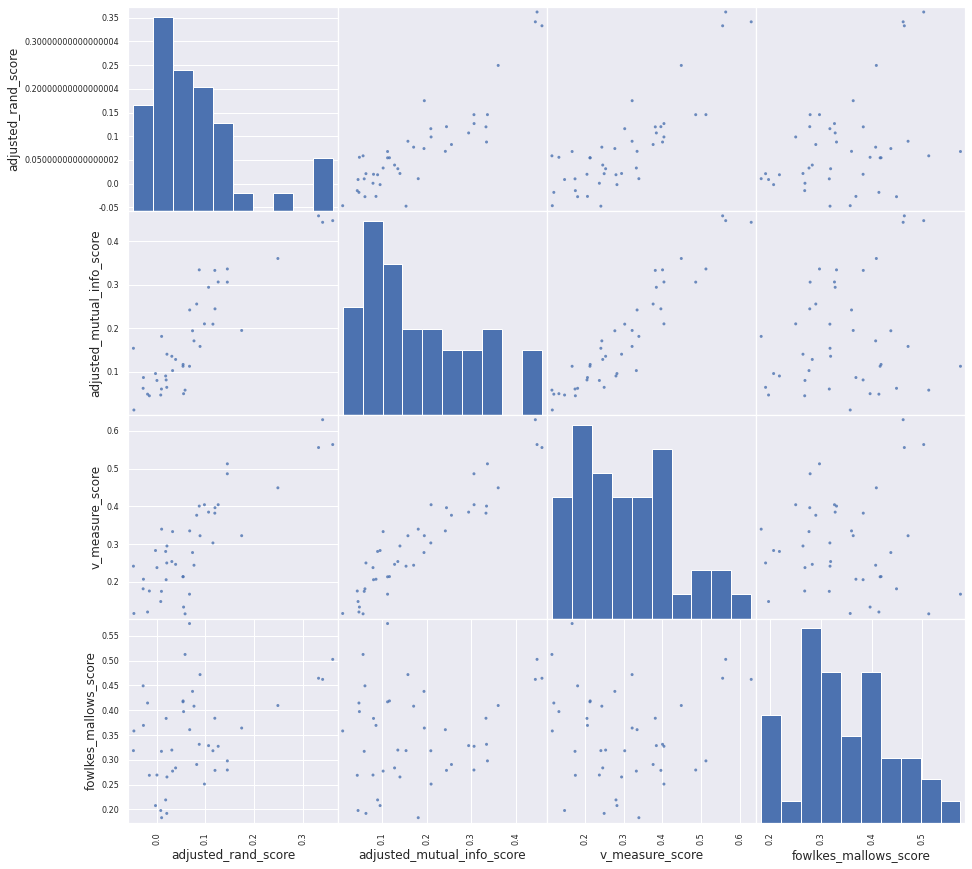

In [304]:
scatter_matrix(scores_df, alpha=0.8, grid=True, figsize=(15, 15))

In [299]:
scores_df.head()

,adjusted_rand_score,adjusted_mutual_info_score,v_measure_score,fowlkes_mallows_score
0,0.054586,0.116794,0.214058,0.418746
1,0.054391,0.112617,0.213437,0.416886
2,0.106910,0.293770,0.384727,0.328503
3,0.082489,0.255386,0.376428,0.290385
4,0.249301,0.359827,0.449069,0.409457


### Visualize Contingency Matrices for Default PubTrends Settings

In [39]:
METRIC_ALIAS = {
    'adjusted_rand_score': 'Rand',
    'adjusted_mutual_info_score': 'Mutual-Info',
    'v_measure_score': 'V-Measure',
    'fowlkes_mallows_score': 'Fowlkes-Mallows'
}

with PdfPages('pubtrends-contingency-matrices.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=False)
            ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
            
            scores = {}
            for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                           v_measure_score, fowlkes_mallows_score]:
                scores[metric.__name__], cm = evaluate_clustering(analyzer, ground_truth, metric)
            
            metrics_str = ", ".join([f'{METRIC_ALIAS[k]}: {v:.2f}' for k, v in scores.items()])
            plt.figure(figsize = (10,7))
            sns.heatmap(cm, annot=True)
            plt.title(f'{filename} - LEVEL {level}\n{metrics_str}')
            plt.xlabel('PubTrends')
            plt.ylabel('Nature Reviews')
            pdf.savefig()
            plt.close()

### Topic Analysis Only for Reference Papers

In [59]:
def evaluate_topic_analysis_for_references(analyzer, ground_truth, pmid, metric):
    """
    Topic analysis as if no second expand step was performed.
    """
    references = list(analyzer.citations_graph.successors(pmid))
    references.append(pmid)
    
    references_similarity_graph = analyzer.similarity_graph.subgraph(references)
    
    settings = AnalyzerSettings()
    topics_dendrogram, partition, comp_other, components, comp_sizes = \
                analyzer.topic_analysis(references_similarity_graph,
                                    topic_min_size=settings.TOPIC_MIN_SIZE,
                                    max_topics_number=settings.TOPICS_MAX_NUMBER,
                                    random_state=settings.SEED,
                                    similarity_bibliographic_coupling=settings.SIMILARITY_BIBLIOGRAPHIC_COUPLING,
                                    similarity_cocitation=settings.SIMILARITY_COCITATION,
                                    similarity_citation=settings.SIMILARITY_CITATION,
                                    similarity_text_citation=settings.SIMILARITY_TEXT_CITATION)
    
    # Get clustering
    actual_clustering = {k: v for k, v in partition.items() if k in ground_truth}
    
    # Align clusterings
    labels_true = []
    labels_pred = []

    for pmid in actual_clustering:
        labels_true.append(ground_truth[pmid])
        labels_pred.append(actual_clustering[pmid])
        
    return metric(labels_true, labels_pred), contingency_matrix(labels_true, labels_pred)

In [60]:
evaluate_topic_analysis_for_references(analyzer, ground_truth, pmid, v_measure_score)

(0.41349863022454475,
 array([[ 5,  0, 15,  0,  1,  0],
        [ 1,  0,  0,  1,  0,  0],
        [ 0,  0,  1,  2,  0,  0],
        [ 5,  1,  1,  1,  0,  0],
        [ 3,  2,  0,  0,  0,  4],
        [ 6,  4,  0,  0,  0,  2],
        [ 3,  4,  0,  0,  0,  0],
        [ 0,  2,  0,  0,  0,  0],
        [ 0,  3,  0,  0,  0,  0],
        [ 5,  2,  0,  0,  0,  0],
        [ 0,  1,  0,  0,  0,  0],
        [ 0,  7,  0,  2,  0,  0],
        [15,  1,  0,  0,  0,  0],
        [ 0,  1,  0,  0,  2,  0]]))

In [61]:
METRIC_ALIAS = {
    'adjusted_rand_score': 'Rand',
    'adjusted_mutual_info_score': 'Mutual-Info',
    'v_measure_score': 'V-Measure',
    'fowlkes_mallows_score': 'Fowlkes-Mallows'
}

with PdfPages('pubtrends-contingency-matrices-refs-only.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=False)
            ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
            
            scores = {}
            for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                           v_measure_score, fowlkes_mallows_score]:
                # Move up, no need to recalculate this amount of times
                scores[metric.__name__], cm = evaluate_topic_analysis_for_references(analyzer, 
                                                                                     ground_truth, 
                                                                                     pmid, metric)
            
            metrics_str = ", ".join([f'{METRIC_ALIAS[k]}: {v:.2f}' for k, v in scores.items()])
            plt.figure(figsize = (10,7))
            sns.heatmap(cm, annot=True)
            plt.title(f'{filename} - LEVEL {level}\n{metrics_str}')
            plt.xlabel('PubTrends')
            plt.ylabel('Nature Reviews')
            pdf.savefig()
            plt.close()

### PubTrends Cluster Sizes

TODO: compare with only-refs setting

In [68]:
from collections import Counter

for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
    pmid, _ = os.path.splitext(filename)
    full_filename = os.path.join(CLUSTERING_FOLDER, filename)
    with open(full_filename, 'r') as f:
        raw_clustering = json.load(f)
    analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
    analyzer = reload_exported_analyzer(analysis_file)
    processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                 include_box_sections=False)
    ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
    actual_clustering = get_clustering(analyzer, ground_truth.keys()).values()
    comp_sizes = Counter(actual_clustering).most_common(3)
    n_papers = len(actual_clustering)
    scaled_sizes = [v * 100 / n_papers for comp, v in comp_sizes]
    print(f"{pmid}\t{scaled_sizes}")

26580716	[84.81012658227849, 5.063291139240507, 5.063291139240507]
26580717	[32.8125, 20.3125, 12.5]
26656254	[50.0, 23.076923076923077, 14.102564102564102]
26678314	[52.99145299145299, 11.11111111111111, 11.11111111111111]
26688349	[30.555555555555557, 25.0, 22.22222222222222]
26688350	[70.0, 10.0, 10.0]
27677859	[69.6969696969697, 9.090909090909092, 7.575757575757576]
27677860	[79.41176470588235, 7.352941176470588, 4.411764705882353]
27834397	[66.95652173913044, 10.434782608695652, 6.956521739130435]
27834398	[70.71428571428571, 13.571428571428571, 5.0]
27904142	[34.42622950819672, 21.311475409836067, 19.672131147540984]
28003656	[86.66666666666667, 4.444444444444445, 3.3333333333333335]
28792006	[48.148148148148145, 13.580246913580247, 7.407407407407407]
28852220	[55.84415584415584, 29.87012987012987, 5.194805194805195]
29147025	[81.30081300813008, 15.447154471544716, 0.8130081300813008]
29170536	[39.784946236559136, 15.053763440860216, 13.978494623655914]
29213134	[72.7272727272727

## PubTrends Export Overview

In [29]:
import pandas as pd

In [40]:
with PdfPages('pubtrends-similarity-parameters-hist.pdf') as pdf:
    for filename in sorted(os.listdir(PUBTRENDS_EXPORT_FOLDER)):
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, filename)
        analyzer = reload_exported_analyzer(analysis_file)
        stats = {
            'cocitation': [],
            'bibcoupling': [],
            'citation': [],
            'text': []
        }
        for _, _, data in analyzer.similarity_graph.edges(data=True):
            for key in stats.keys():
                stats[key].append(data.get(key, 0))

        stats_df = pd.DataFrame(stats).apply(pd.to_numeric, errors='coerce')
        ax = stats_df.hist(log=True)
        plt.suptitle(filename)
        pdf.savefig()
        plt.close()